# Setup Folders

In [1]:
import os

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    if not os.path.exists("src"):
        !git clone https://github.com/HenriqueSchmitz/world-models-implementation temp_repo
        !mv temp_repo/* .
        !rm -rf temp_repo
        !sudo apt-get install -y swig
        %pip install -q -r requirements.txt

In [2]:
import os
from src.utils.colab import is_environment_colab_notebook
from src.utils.secrets import get_secret

project_folder = get_secret("worldModelsFolderPath") if is_environment_colab_notebook() else "./"
settings_path = os.path.join(project_folder, "settings.json")
settings_path = settings_path if os.path.exists(settings_path) else  "./settings.json"
data_folder = os.path.join(project_folder, "data")
output_folder = os.path.join(project_folder, "weights/vae")
os.makedirs(output_folder, exist_ok=True)

local_data_folder = None
if is_environment_colab_notebook():
    local_data_folder = "/content/data"
    os.makedirs(local_data_folder, exist_ok=True)

# Training Settings

In [3]:
from src.utils.logging import get_logger
LOG_LEVEL = "INFO"
logger = get_logger(LOG_LEVEL)

2025-12-15 11:47:53 [INFO] Logger initialized.


In [4]:
import json

with open(settings_path, "r") as settings_file:
    settings = json.load(settings_file)
    IMAGE_CHANNELS = settings["vae"]["model"]["image_channels"]
    OBSERVATION_DIM = settings["vae"]["model"]["observation_dim"]
    HIDDEN_DIM = settings["vae"]["model"]["hidden_dim"]
    REPRESENTATION_DIM = settings["vae"]["model"]["representation_dim"]

    EPOCHS = settings["vae"]["train"]["epochs"]
    LR = settings["vae"]["train"]["learning_rate"]
    MAX_NORM = settings["vae"]["train"]["max_norm"]
    KLD_BETA = settings["vae"]["train"]["kld_beta"]
    TRAIN_RATIO = settings["vae"]["train"]["train_ratio"]
    EPOCHS_BETWEEN_TESTS = settings["vae"]["train"]["epochs_between_tests"]
    BATCH_SIZE = settings["vae"]["train"]["batch_size"]
    NUM_PRELOAD_FILES = settings["vae"]["train"]["num_preload_files"]
    NUM_DATASET_WORKERS = settings["vae"]["train"]["num_dataset_workers"]
    EARLY_STOPPING_TOLERANCE = settings["vae"]["train"]["early_stopping_tolerance"]
    EARLY_STOPPING_MIN_DELTA = settings["vae"]["train"]["early_stopping_min_delta"]
    TRAIN_IMAGE_LOG_INTERVAL = settings["vae"]["train"]["train_image_log_interval"]

WANDB_PROJECT = "world-models-paper"
WANDB_RUN_NAME = "vae"

def log_settings():
    logger.info(f"IMAGE_CHANNELS: {IMAGE_CHANNELS}")
    logger.info(f"OBSERVATION_DIM: {OBSERVATION_DIM}")
    logger.info(f"HIDDEN_DIM: {HIDDEN_DIM}")
    logger.info(f"REPRESENTATION_DIM: {REPRESENTATION_DIM}")
    logger.info("========================================")
    logger.info(f"EPOCHS: {EPOCHS}")
    logger.info(f"LR: {LR}")
    logger.info(f"MAX_NORM: {MAX_NORM}")
    logger.info(f"KLD_BETA: {KLD_BETA}")
    logger.info(f"TRAIN_RATIO: {TRAIN_RATIO}")
    logger.info(f"EPOCHS_BETWEEN_TESTS: {EPOCHS_BETWEEN_TESTS}")
    logger.info(f"BATCH_SIZE: {BATCH_SIZE}")
    logger.info(f"NUM_PRELOAD_FILES: {NUM_PRELOAD_FILES}")
    logger.info(f"NUM_DATASET_WORKERS: {NUM_DATASET_WORKERS}")
    logger.info(f"EARLY_STOPPING_TOLERANCE: {EARLY_STOPPING_TOLERANCE}")
    logger.info(f"EARLY_STOPPING_MIN_DELTA: {EARLY_STOPPING_MIN_DELTA}")
    logger.info(f"TRAIN_IMAGE_LOG_INTERVAL: {TRAIN_IMAGE_LOG_INTERVAL}")
    logger.info("========================================")
    logger.info(f"WANDB_PROJECT: {WANDB_PROJECT}")
    logger.info(f"WANDB_RUN_NAME: {WANDB_RUN_NAME}")

log_settings()

2025-12-15 11:47:53 [INFO] IMAGE_CHANNELS: 3
2025-12-15 11:47:53 [INFO] OBSERVATION_DIM: 64
2025-12-15 11:47:53 [INFO] HIDDEN_DIM: 1024
2025-12-15 11:47:53 [INFO] REPRESENTATION_DIM: 32
2025-12-15 11:47:53 [INFO] ========================================
2025-12-15 11:47:53 [INFO] EPOCHS: 200
2025-12-15 11:47:53 [INFO] LR: 0.001
2025-12-15 11:47:53 [INFO] MAX_NORM: 0.1
2025-12-15 11:47:53 [INFO] KLD_BETA: 2
2025-12-15 11:47:53 [INFO] TRAIN_RATIO: 0.8
2025-12-15 11:47:53 [INFO] EPOCHS_BETWEEN_TESTS: 5
2025-12-15 11:47:53 [INFO] BATCH_SIZE: 1024
2025-12-15 11:47:53 [INFO] NUM_PRELOAD_FILES: 10
2025-12-15 11:47:53 [INFO] NUM_DATASET_WORKERS: 8
2025-12-15 11:47:53 [INFO] EARLY_STOPPING_TOLERANCE: 3
2025-12-15 11:47:53 [INFO] EARLY_STOPPING_MIN_DELTA: 0.01
2025-12-15 11:47:53 [INFO] TRAIN_IMAGE_LOG_INTERVAL: 1000
2025-12-15 11:47:53 [INFO] ========================================
2025-12-15 11:47:53 [INFO] WANDB_PROJECT: world-models-paper
2025-12-15 11:47:53 [INFO] WANDB_RUN_NAME: vae


# Setup

In [5]:
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader

from src.datasets.observations_dataset import ObservationsDataset
from src.models.vae import ConvVAE
from src.training.early_stopping import EarlyStopping
from src.training.vae_trainer import ConvVaeTrainer
from src.utils.torch import get_device

In [6]:
DEVICE = get_device(logger)

2025-12-15 11:47:55 [INFO] Using device: mps:0


# Load Dataset

In [7]:
train_dataset, test_dataset = ObservationsDataset.train_test_split(data_folder,
                                                                   local_data_folder=local_data_folder,
                                                                   num_preloaded_files=NUM_PRELOAD_FILES,
                                                                   num_workers=NUM_DATASET_WORKERS,
                                                                   train_ratio=TRAIN_RATIO,
                                                                   shuffle_files=True,
                                                                   shuffle_file_samples=True,
                                                                   logger=logger)

In [8]:
train_size = len(train_dataset)
test_size = len(test_dataset)
logger.info(f"Train: {train_size}")
logger.info(f"Test: {test_size}")

2025-12-15 11:47:55 [INFO] Train: 1245818
2025-12-15 11:47:55 [INFO] Test: 298326


In [9]:
example_observation = next(train_dataset)
logger.info(example_observation.shape)

2025-12-15 11:47:55 [INFO] torch.Size([3, 64, 64])


In [10]:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [11]:
train_batches = len(train_dataloader)
test_batches = len(test_dataloader)
logger.info(f"Train batches: {train_batches}")
logger.info(f"Test batches: {test_batches}")

2025-12-15 11:47:55 [INFO] Train batches: 1217
2025-12-15 11:47:55 [INFO] Test batches: 292


# Train

In [12]:
model = ConvVAE(image_channels=IMAGE_CHANNELS,
                h_dim=HIDDEN_DIM,
                z_dim=REPRESENTATION_DIM,
                device=DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
early_stopping = EarlyStopping(tolerance=EARLY_STOPPING_TOLERANCE, min_delta=EARLY_STOPPING_MIN_DELTA)

In [13]:
try:
    wandb_setup = {
        "api_key": get_secret('wandbApiKey'),
        "project": WANDB_PROJECT,
        "run_name": WANDB_RUN_NAME,
        "config": {
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LR,
            "train_dataset_size": train_size,
            "test_dataset_size": test_size,
            "train_batches": train_batches,
            "test_batches": test_batches
        }
    }
except Exception as e:
    logger.error(f"Ignoring wandb logging, could not retrieve wandbApiKey secret. Error: {str(e)}")
    wandb_setup = None

In [14]:
trainer = ConvVaeTrainer(model=model,
                         weights_folder=output_folder,
                         train_dataloader=train_dataloader,
                         optimizer=optimizer,
                         num_epochs=EPOCHS,
                         batch_size=BATCH_SIZE,
                         kld_beta=KLD_BETA,
                         train_image_log_interval=TRAIN_IMAGE_LOG_INTERVAL,
                         load_checkpoint=True,
                         max_norm=MAX_NORM,
                         device=DEVICE,
                         test_dataloader=test_dataloader,
                         epochs_between_tests=EPOCHS_BETWEEN_TESTS,
                         early_stopper=early_stopping,
                         wandb_setup=wandb_setup,
                         logger=logger)

2025-12-15 11:47:56 [INFO] Resuming training from: ./weights/vae/epoch_84.pth


In [15]:
# Repeat logging of important information so it is available on wandb run
log_settings()
_ = get_device(logger)

2025-12-15 11:47:58 [INFO] IMAGE_CHANNELS: 3
2025-12-15 11:47:58 [INFO] OBSERVATION_DIM: 64
2025-12-15 11:47:58 [INFO] HIDDEN_DIM: 1024
2025-12-15 11:47:58 [INFO] REPRESENTATION_DIM: 32
2025-12-15 11:47:58 [INFO] ========================================
2025-12-15 11:47:58 [INFO] EPOCHS: 200
2025-12-15 11:47:58 [INFO] LR: 0.001
2025-12-15 11:47:58 [INFO] MAX_NORM: 0.1
2025-12-15 11:47:58 [INFO] KLD_BETA: 2
2025-12-15 11:47:58 [INFO] TRAIN_RATIO: 0.8
2025-12-15 11:47:58 [INFO] EPOCHS_BETWEEN_TESTS: 5
2025-12-15 11:47:58 [INFO] BATCH_SIZE: 1024
2025-12-15 11:47:58 [INFO] NUM_PRELOAD_FILES: 10
2025-12-15 11:47:58 [INFO] NUM_DATASET_WORKERS: 8
2025-12-15 11:47:58 [INFO] EARLY_STOPPING_TOLERANCE: 3
2025-12-15 11:47:58 [INFO] EARLY_STOPPING_MIN_DELTA: 0.01
2025-12-15 11:47:58 [INFO] TRAIN_IMAGE_LOG_INTERVAL: 1000
2025-12-15 11:47:58 [INFO] ========================================
2025-12-15 11:47:58 [INFO] WANDB_PROJECT: world-models-paper
2025-12-15 11:47:58 [INFO] WANDB_RUN_NAME: vae
2025-

In [16]:
model = trainer.train()

Epoch:   0%|          | 0/200 [00:00<?, ?epoch/s]

Train Epoch 84:   0%|          | 0/1217 [00:00<?, ?batch/s]

Test Epoch 84:   0%|          | 0/292 [00:00<?, ?batch/s]

2025-12-15 12:01:46 [INFO] Epoch 85 Training Loss: 24.4530
2025-12-15 12:03:23 [INFO] Epoch 85 Test Loss: 23.9041
2025-12-15 12:17:37 [INFO] Epoch 86 Training Loss: 24.4914
2025-12-15 12:31:50 [INFO] Epoch 87 Training Loss: 24.4962
2025-12-15 12:46:06 [INFO] Epoch 88 Training Loss: 24.4463
2025-12-15 13:00:57 [INFO] Epoch 89 Training Loss: 24.4503
2025-12-15 13:16:11 [INFO] Epoch 90 Training Loss: 24.4120
2025-12-15 13:17:55 [INFO] Epoch 90 Test Loss: 24.2638
2025-12-15 13:33:33 [INFO] Epoch 91 Training Loss: 24.4213
2025-12-15 13:49:17 [INFO] Epoch 92 Training Loss: 24.3661
2025-12-15 14:04:59 [INFO] Epoch 93 Training Loss: 24.3544
2025-12-15 14:19:43 [INFO] Epoch 94 Training Loss: 24.3787
2025-12-15 14:34:45 [INFO] Epoch 95 Training Loss: 24.3565
2025-12-15 14:36:25 [INFO] Epoch 95 Test Loss: 24.4053
2025-12-15 14:51:49 [INFO] Epoch 96 Training Loss: 24.3805
2025-12-15 15:07:10 [INFO] Epoch 97 Training Loss: 24.3389
2025-12-15 15:22:20 [INFO] Epoch 98 Training Loss: 24.3303
2025-12-1

# Testing

In [17]:
def test_observation(model, observation):
    model.eval()
    with torch.no_grad():
        z, _, _ = model.encode(observation.unsqueeze(0))
        decoded = model.decode(z)
    _, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(observation.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title('Original Observation')
    axes[0].axis('off')
    axes[1].imshow(decoded.squeeze(0).permute(1, 2, 0).cpu().numpy())
    axes[1].set_title('Decoded Observation')
    axes[1].axis('off')
    plt.show()

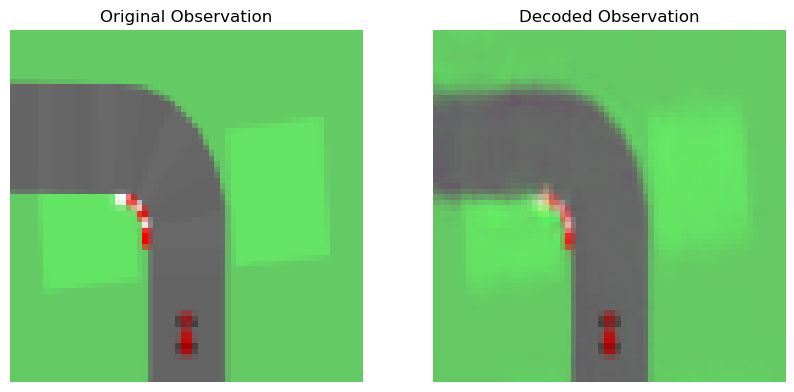

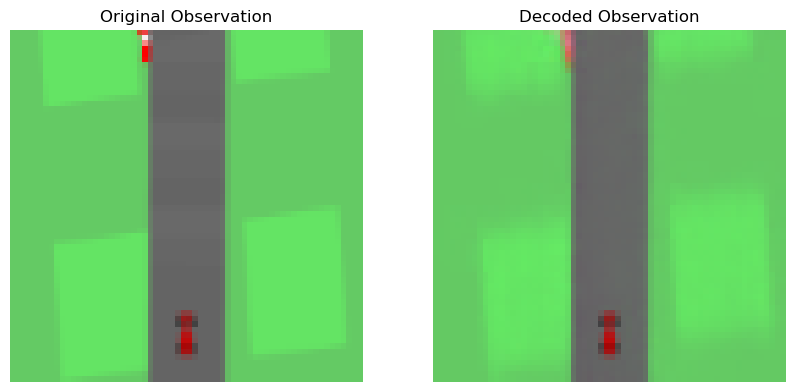

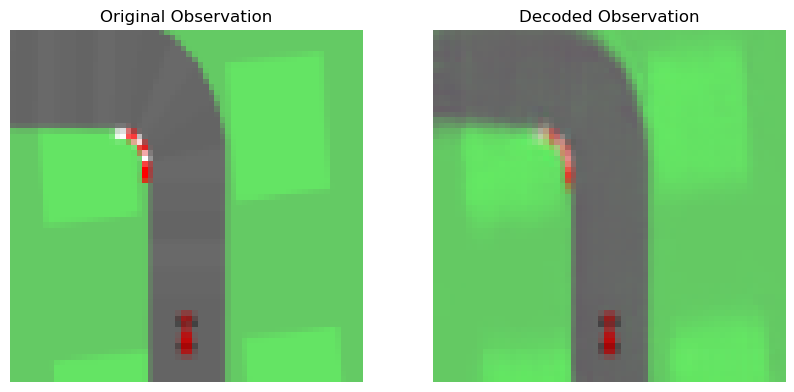

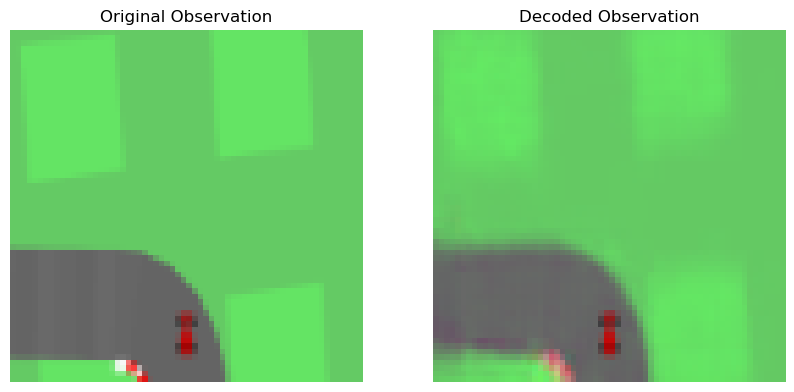

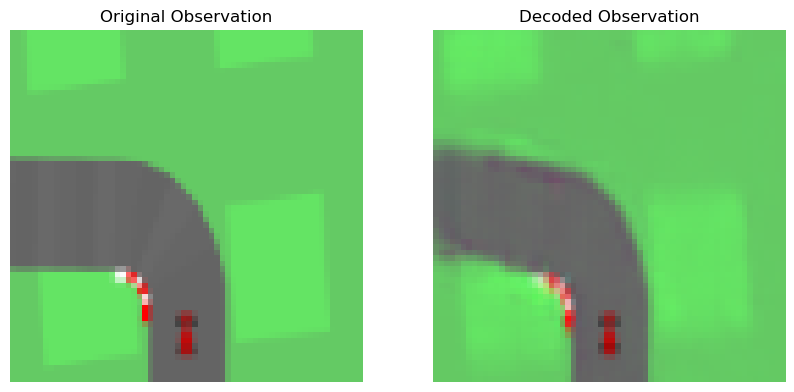

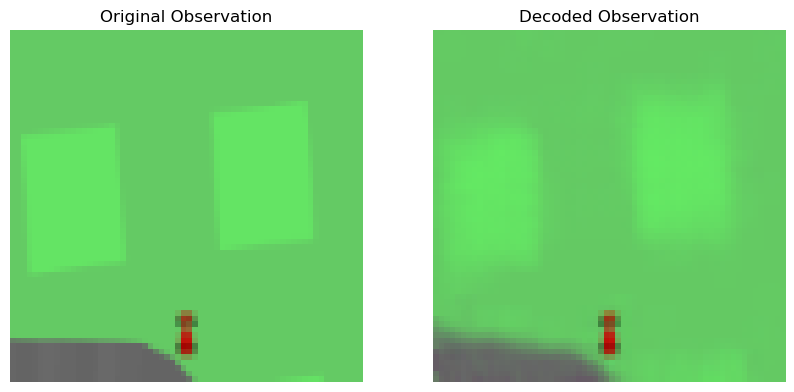

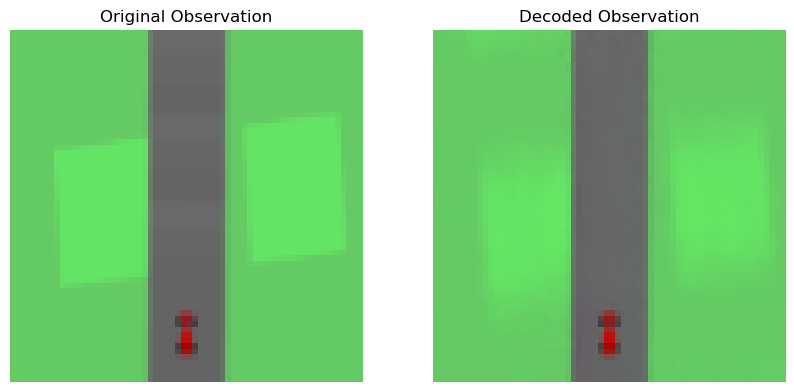

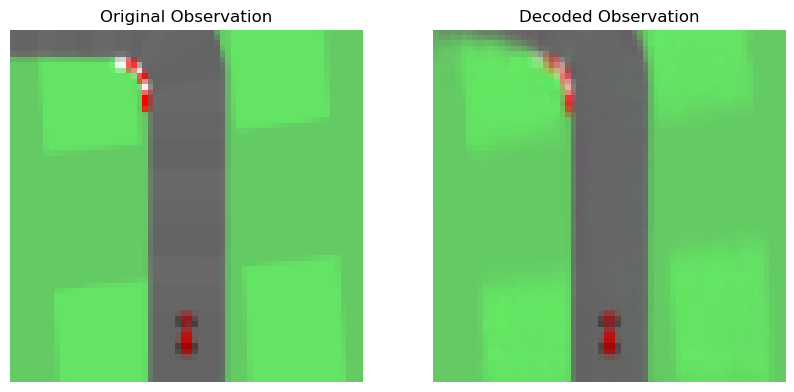

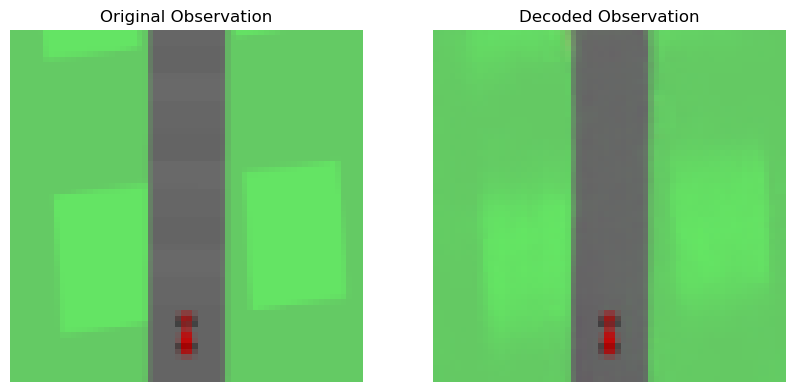

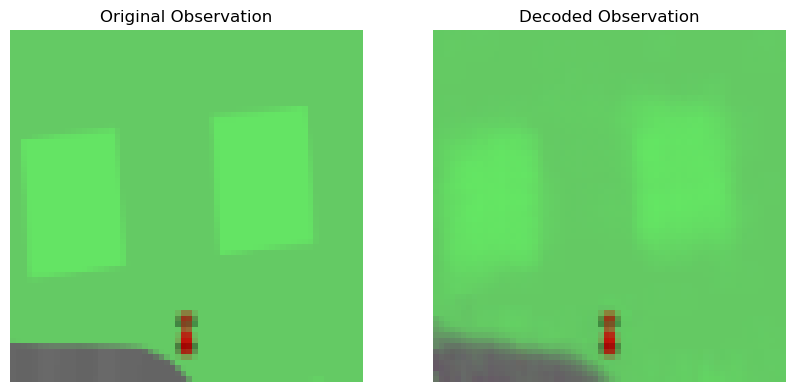

In [18]:
i = 0
for example_observation in iter(test_dataset):
    test_observation(model, example_observation.to(DEVICE))
    i += 1
    if i == 10:
        break